In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
# Import all required metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv(r"C:\Users\rpap9\OneDrive\Desktop\ML Project\CarPrice_Assignment.csv")

In [3]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [5]:
print("\n---Checking for Missing Values ---")
print(df.isnull().sum())
print("Observation: No missing values detected.")


---Checking for Missing Values ---
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64
Observation: No missing values detected.


In [6]:
print("\n---Extracting Company Name ---")
df_processed = df.copy() # Work on a copy
df_processed['CompanyName'] = df_processed['CarName'].apply(lambda x: x.split(' ')[0])
print("Showing 'CarName' and extracted 'CompanyName' (first 5 rows):")
print(df_processed[['CarName', 'CompanyName']].head())
print("\nUnique Company Names extracted (before correction):", sorted(df_processed['CompanyName'].unique()))


---Extracting Company Name ---
Showing 'CarName' and extracted 'CompanyName' (first 5 rows):
                    CarName  CompanyName
0        alfa-romero giulia  alfa-romero
1       alfa-romero stelvio  alfa-romero
2  alfa-romero Quadrifoglio  alfa-romero
3               audi 100 ls         audi
4                audi 100ls         audi

Unique Company Names extracted (before correction): ['Nissan', 'alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'maxda', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porcshce', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'toyouta', 'vokswagen', 'volkswagen', 'volvo', 'vw']


In [7]:
print("\n--- Correcting Company Name Typos ---")
company_corrections = {
    'maxda': 'mazda', 'porcshce': 'porsche', 'toyouta': 'toyota',
    'vokswagen': 'volkswagen', 'vw': 'volkswagen', 'Nissan': 'nissan'
}
df_processed['CompanyName'] = df_processed['CompanyName'].replace(company_corrections)
print("Unique Company Names (after correction):", sorted(df_processed['CompanyName'].unique()))


--- Correcting Company Name Typos ---
Unique Company Names (after correction): ['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


In [8]:
print("\n---Dropping 'car_ID' and 'CarName' ---")
df_processed = df_processed.drop(['car_ID', 'CarName'], axis=1)
print("Columns dropped.")
print("Shape after dropping columns:", df_processed.shape)
print("Remaining columns:", df_processed.columns.tolist())


---Dropping 'car_ID' and 'CarName' ---
Columns dropped.
Shape after dropping columns: (205, 25)
Remaining columns: ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'CompanyName']



---Analyzing Target Variable 'price' ---


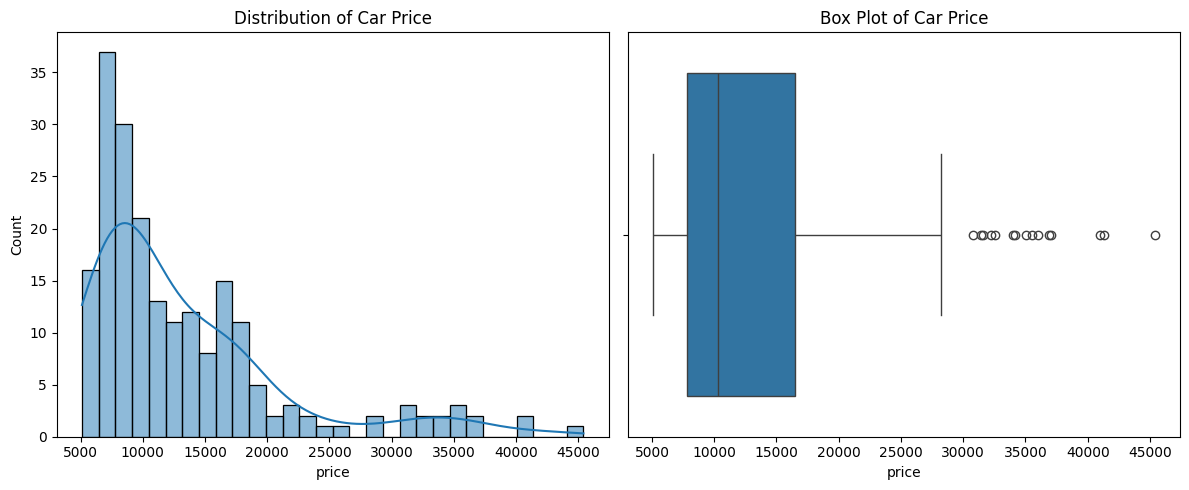

Skewness of price: 1.78. Observation: Right-skewed.


In [11]:
print("\n---Analyzing Target Variable 'price' ---")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); sns.histplot(df_processed['price'], kde=True, bins=30); plt.title('Distribution of Car Price')
plt.subplot(1, 2, 2); sns.boxplot(x=df_processed['price']); plt.title('Box Plot of Car Price')
plt.tight_layout(); plt.show()
print(f"Skewness of price: {df_processed['price'].skew():.2f}. Observation: Right-skewed.")

f. Example EDA Plot: Engine Size vs Price ---
Top 5 features correlated with price:
 price         1.000000
enginesize    0.874145
curbweight    0.835305
horsepower    0.808139
carwidth      0.759325
carlength     0.682920
Name: price, dtype: float64


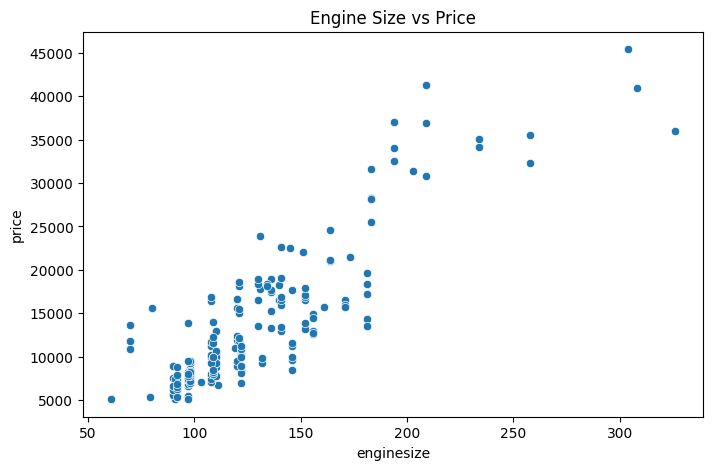

Observation: Positive correlation visible.


In [14]:
print("\3f. Example EDA Plot: Engine Size vs Price ---")
numeric_cols_for_corr = df_processed.select_dtypes(include=np.number)
correlation_with_price = numeric_cols_for_corr.corr()['price'].sort_values(ascending=False)
print("Top 5 features correlated with price:\n", correlation_with_price.head(6))
plt.figure(figsize=(8, 5))
sns.scatterplot(x='enginesize', y='price', data=df_processed); plt.title('Engine Size vs Price'); plt.show()
print("Observation: Positive correlation visible.")


--- Example EDA Plot: Company Name vs Price ---


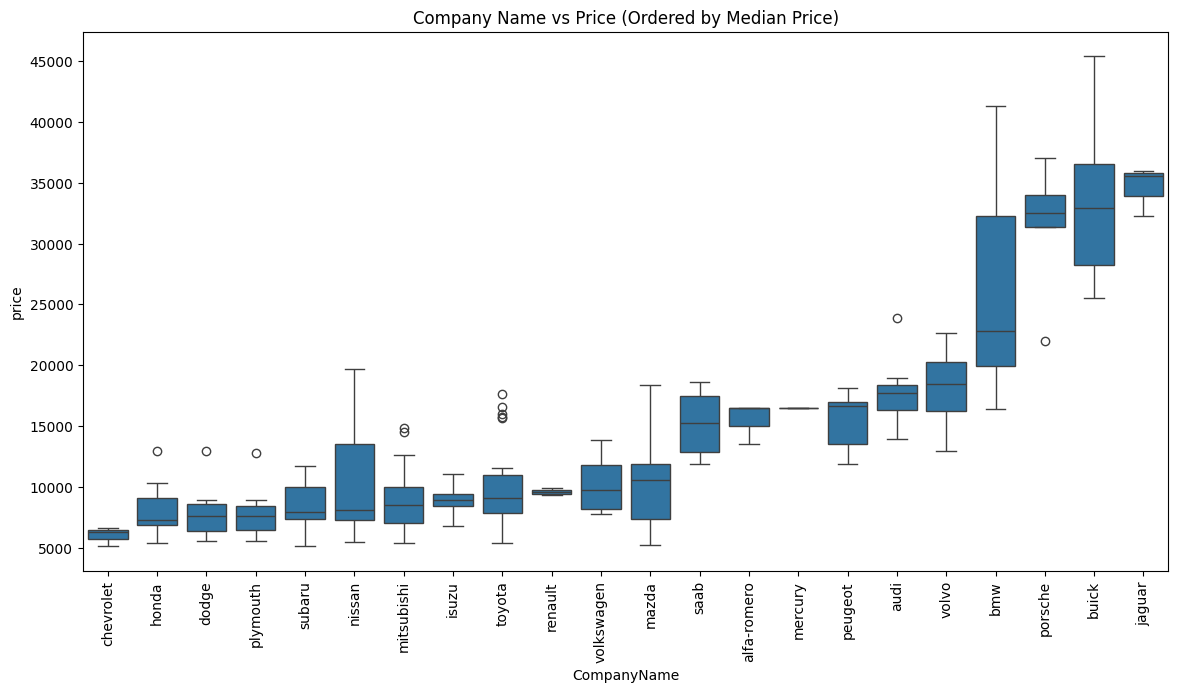

Observation: Significant price variation between brands.


In [15]:
print("\n--- Example EDA Plot: Company Name vs Price ---")
plt.figure(figsize=(14, 7))
company_order = df_processed.groupby('CompanyName')['price'].median().sort_values().index
sns.boxplot(x='CompanyName', y='price', data=df_processed, order=company_order)
plt.xticks(rotation=90); plt.title('Company Name vs Price (Ordered by Median Price)'); plt.show()
print("Observation: Significant price variation between brands.")

In [16]:
print("\n---  Starting Data Pre-processing ---")

# Define Features (X) and Target (y)
print("\n--- Separating Features (X) and Target (y) ---")
X = df_processed.drop('price', axis=1)
y = df_processed['price']
print("Features (X) initial shape:", X.shape)
print("Target (y) initial shape:", y.shape)


---  Starting Data Pre-processing ---

--- Separating Features (X) and Target (y) ---
Features (X) initial shape: (205, 24)
Target (y) initial shape: (205,)


In [17]:
print("\n---Applying Log Transformation to Target Variable 'price' ---")
y_log = np.log1p(y) # log1p is log(1+y)
print("Target variable 'y' log-transformed.")
print("Original 'y' head:\n", y.head())
print("Log-transformed 'y_log' head:\n", y_log.head())


---Applying Log Transformation to Target Variable 'price' ---
Target variable 'y' log-transformed.
Original 'y' head:
 0    13495.0
1    16500.0
2    16500.0
3    13950.0
4    17450.0
Name: price, dtype: float64
Log-transformed 'y_log' head:
 0    9.510149
1    9.711176
2    9.711176
3    9.543306
4    9.767152
Name: price, dtype: float64


In [18]:
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print("\nNumerical features identified in X:", numerical_cols)
print("Categorical features identified in X:", categorical_cols)


Numerical features identified in X: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Categorical features identified in X: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'CompanyName']


In [19]:
print("\n---Converting Categorical Features using pd.get_dummies ---")
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Shape of X after creating dummy variables:", X.shape)
print("\n--- First 5 Rows of X (After get_dummies) ---")
print(X.head())


---Converting Categorical Features using pd.get_dummies ---
Shape of X after creating dummy variables: (205, 64)

--- First 5 Rows of X (After get_dummies) ---
   symboling  wheelbase  carlength  carwidth  carheight  curbweight  \
0          3       88.6      168.8      64.1       48.8        2548   
1          3       88.6      168.8      64.1       48.8        2548   
2          1       94.5      171.2      65.5       52.4        2823   
3          2       99.8      176.6      66.2       54.3        2337   
4          2       99.4      176.6      66.4       54.3        2824   

   enginesize  boreratio  stroke  compressionratio  ...  CompanyName_nissan  \
0         130       3.47    2.68               9.0  ...               False   
1         130       3.47    2.68               9.0  ...               False   
2         152       2.68    3.47               9.0  ...               False   
3         109       3.19    3.40              10.0  ...               False   
4         136    

In [20]:
print("\n--- Splitting Data into Training and Testing Sets (80/20 split) ---")
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape); print("X_test shape:", X_test.shape)
print("y_train_log shape:", y_train_log.shape); print("y_test_log shape:", y_test_log.shape)


--- Splitting Data into Training and Testing Sets (80/20 split) ---
X_train shape: (164, 64)
X_test shape: (41, 64)
y_train_log shape: (164,)
y_test_log shape: (41,)


In [21]:
print("\n---Scaling Numerical Features using StandardScaler ---")
scaler = StandardScaler()
numerical_cols_in_X = [col for col in numerical_cols if col in X_train.columns]
print("Numerical columns being scaled:", numerical_cols_in_X)
# Fit on training data ONLY, transform both train and test
X_train[numerical_cols_in_X] = scaler.fit_transform(X_train[numerical_cols_in_X])
X_test[numerical_cols_in_X] = scaler.transform(X_test[numerical_cols_in_X])
print("Numerical features scaled.")
print("\n--- First 5 Rows of Scaled X_train (Showing only original numerical columns) ---")
print(X_train[numerical_cols_in_X].head())


---Scaling Numerical Features using StandardScaler ---
Numerical columns being scaled: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Numerical features scaled.

--- First 5 Rows of Scaled X_train (Showing only original numerical columns) ---
     symboling  wheelbase  carlength  carwidth  carheight  curbweight  \
66   -0.727380   1.037085   0.072450  0.083817   0.276779    0.281287   
111  -0.727380   1.541231   1.043916  1.170268   1.207269    1.016045   
153  -0.727380  -0.508962  -0.367616 -1.097108   2.178216   -0.541642   
96    0.078636  -0.710620  -0.732953 -1.002634   0.317235   -1.147082   
38   -0.727380  -0.374523  -0.550285 -0.341316  -0.168238   -0.524008   

     enginesize  boreratio    stroke  compressionratio  horsepower   peakrpm  \
66     0.188010   0.405836  1.215101          3.099860   -0.815386 -1.917829   
111   -0.158993   

In [22]:
print("\n---Training Baseline Linear Regression Model ---")
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train_log)
print("Baseline model training completed.")


---Training Baseline Linear Regression Model ---
Baseline model training completed.


In [23]:
print("\n--- Making Predictions with Baseline Model ---")
y_pred_log_baseline = baseline_model.predict(X_test)
print("Baseline predictions made (log scale).")


--- Making Predictions with Baseline Model ---
Baseline predictions made (log scale).


In [24]:
print("\n---Evaluating Baseline Model ---")
# Inverse transform predictions and actual values
y_pred_baseline = np.expm1(y_pred_log_baseline)
y_test = np.expm1(y_test_log) # Inverse transform y_test_log once
y_pred_baseline[y_pred_baseline < 0] = 0 # Handle potential negatives

print("Baseline predictions and actual test values converted back to original scale.")
print("\nActual Test Prices (First 5):", y_test.head().values.round(2))
print("Predicted Baseline Prices (First 5):", y_pred_baseline[:5].round(2))

# Calculate all metrics for Baseline Model
r2_base = r2_score(y_test, y_pred_baseline)
mae_base = mean_absolute_error(y_test, y_pred_baseline)
mse_base = mean_squared_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mse_base)

print(f"\nBaseline Model Performance Metrics on Test Set:")
print(f"  R-squared (R2):           {r2_base:.4f}")
print(f"  Mean Absolute Error (MAE):  {mae_base:.2f}")
print(f"  Mean Squared Error (MSE):   {mse_base:.2f}")
print(f"  Root Mean Squared Error (RMSE):{rmse_base:.2f}")
if r2_base > 0.90: print("  Target R-squared (> 0.90) Achieved!")
else: print(f"  Target R-squared (> 0.90) NOT Achieved (Current: {r2_base:.4f})")


---Evaluating Baseline Model ---
Baseline predictions and actual test values converted back to original scale.

Actual Test Prices (First 5): [30760.   17859.17  9549.   11850.   28248.  ]
Predicted Baseline Prices (First 5): [31359.63 24100.82  9395.07 12311.44 26920.16]

Baseline Model Performance Metrics on Test Set:
  R-squared (R2):           0.9074
  Mean Absolute Error (MAE):  1676.52
  Mean Squared Error (MSE):   7312140.76
  Root Mean Squared Error (RMSE):2704.10
  Target R-squared (> 0.90) Achieved!


In [25]:
print("\n--- Hyperparameter Tuning Introduction ---")
print("Standard Linear Regression doesn't have significant hyperparameters for tuning.")
print("We will use Ridge Regression (Linear Regression with L2 regularization) to demonstrate tuning.")
print("Ridge adds a penalty based on the square of the magnitude of coefficients (controlled by 'alpha').")
print("This helps prevent overfitting and can improve generalization.")

# Define the parameter grid for alpha (regularization strength)
# Use a logarithmic scale for alpha as its effect often spans orders of magnitude
param_grid = {'alpha': np.logspace(-4, 2, 10)} # Example: 10 values from 0.0001 to 100

print("\nParameter grid for Ridge 'alpha':", param_grid['alpha'])

# Create a Ridge regression object
ridge = Ridge()

# Set up GridSearchCV
# cv=5 means 5-fold cross-validation
# scoring='neg_mean_squared_error' - GridSearchCV maximizes score, so we use negative MSE (lower MSE is better)
grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5,
                           scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
# n_jobs=-1 uses all available CPU cores
# verbose=1 shows progress

print("\n--- Starting GridSearchCV for Ridge Regression ---")
# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train_log)

# Get the best parameters and the best estimator
best_alpha = grid_search.best_params_['alpha']
best_tuned_model = grid_search.best_estimator_ # This is the Ridge model with the best alpha

print(f"\n--- GridSearchCV Complete ---")
print(f"Best alpha found: {best_alpha:.6f}")
print("Best estimator (tuned Ridge model):", best_tuned_model)


--- Hyperparameter Tuning Introduction ---
Standard Linear Regression doesn't have significant hyperparameters for tuning.
We will use Ridge Regression (Linear Regression with L2 regularization) to demonstrate tuning.
Ridge adds a penalty based on the square of the magnitude of coefficients (controlled by 'alpha').
This helps prevent overfitting and can improve generalization.

Parameter grid for Ridge 'alpha': [1.00000000e-04 4.64158883e-04 2.15443469e-03 1.00000000e-02
 4.64158883e-02 2.15443469e-01 1.00000000e+00 4.64158883e+00
 2.15443469e+01 1.00000000e+02]

--- Starting GridSearchCV for Ridge Regression ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- GridSearchCV Complete ---
Best alpha found: 0.215443
Best estimator (tuned Ridge model): Ridge(alpha=np.float64(0.21544346900318823))


In [26]:
print("\n--- Making Predictions with Tuned Ridge Model ---")
y_pred_log_tuned = best_tuned_model.predict(X_test)
print("Tuned model predictions made (log scale).")


--- Making Predictions with Tuned Ridge Model ---
Tuned model predictions made (log scale).


In [28]:
print("\n---Evaluating Tuned Ridge Model ---")
# Inverse transform predictions
y_pred_tuned = np.expm1(y_pred_log_tuned)
y_pred_tuned[y_pred_tuned < 0] = 0 # Handle potential negatives

print("Tuned predictions converted back to original scale.")
print("\nActual Test Prices (First 5):", y_test.head().values.round(2)) # y_test is already inverse transformed
print("Predicted Tuned Prices (First 5):", y_pred_tuned[:5].round(2))

# Calculate all metrics for Tuned Model
r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)

print(f"\nTuned Ridge Model Performance Metrics on Test Set:")
print(f"  R-squared (R2):           {r2_tuned:.4f}")
print(f"  Mean Absolute Error (MAE):  {mae_tuned:.2f}")
print(f"  Mean Squared Error (MSE):   {mse_tuned:.2f}")
print(f"  Root Mean Squared Error (RMSE):{rmse_tuned:.2f}")
if r2_tuned > 0.90: print("  Target R-squared (> 0.90) Achieved!")
else: print(f"  Target R-squared (> 0.90) NOT Achieved (Current: {r2_tuned:.4f})")


---Evaluating Tuned Ridge Model ---
Tuned predictions converted back to original scale.

Actual Test Prices (First 5): [30760.   17859.17  9549.   11850.   28248.  ]
Predicted Tuned Prices (First 5): [30591.78 22832.19  9086.47 12857.96 28194.15]

Tuned Ridge Model Performance Metrics on Test Set:
  R-squared (R2):           0.9376
  Mean Absolute Error (MAE):  1525.20
  Mean Squared Error (MSE):   4923549.17
  Root Mean Squared Error (RMSE):2218.91
  Target R-squared (> 0.90) Achieved!


In [29]:
print("\n--- Performance Comparison ---")
print(f"Metric        | Baseline LinearReg | Tuned Ridge (alpha={best_alpha:.4f})")
print(f"--------------|--------------------|---------------------------")
print(f"R2 Score      | {r2_base:18.4f} | {r2_tuned:25.4f}")
print(f"MAE           | {mae_base:18.2f} | {mae_tuned:25.2f}")
print(f"RMSE          | {rmse_base:18.2f} | {rmse_tuned:25.2f}")
# Small improvements are common with Ridge/Lasso unless there was significant overfitting initially


--- Step 11: Performance Comparison ---
Metric        | Baseline LinearReg | Tuned Ridge (alpha=0.2154)
--------------|--------------------|---------------------------
R2 Score      |             0.9074 |                    0.9376
MAE           |            1676.52 |                   1525.20
RMSE          |            2704.10 |                   2218.91



--- Visualizing Tuned Model Predictions vs. Actual Prices ---


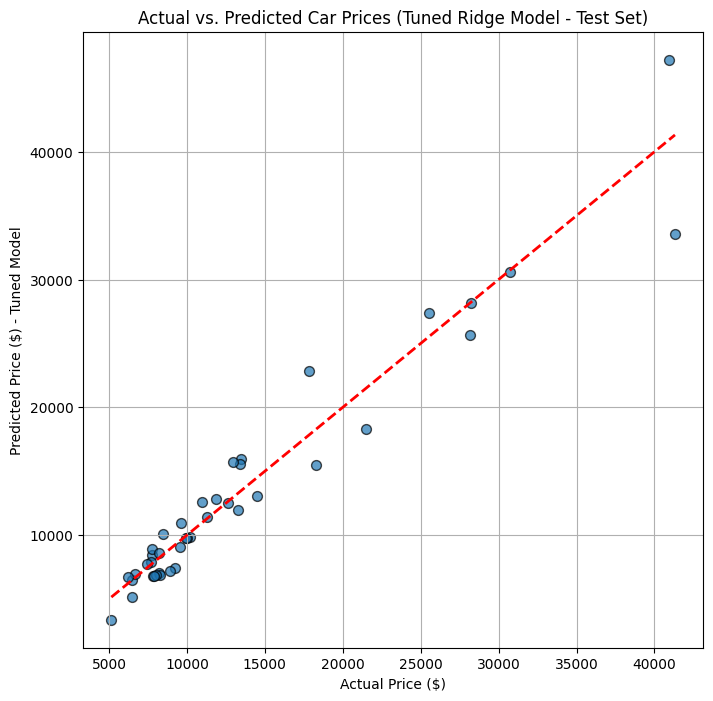


--- Optional: Residual Plot for Tuned Model ---


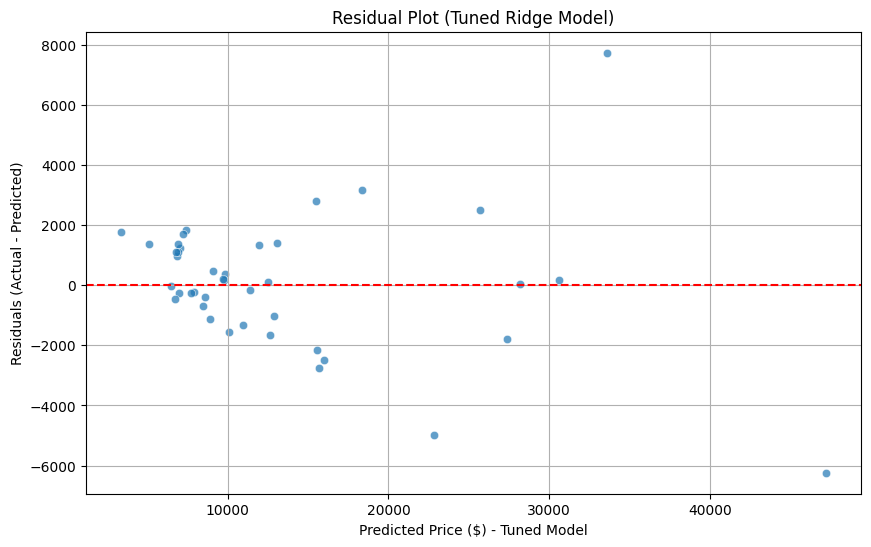

Observation: Residuals should ideally be randomly scattered around zero without obvious patterns.

--- Full Analysis Complete ---


In [31]:
print("\n--- Visualizing Tuned Model Predictions vs. Actual Prices ---")
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_tuned, alpha=0.7, edgecolors='k', s=50) # Plot actual vs predicted (tuned)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Diagonal line
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($) - Tuned Model')
plt.title('Actual vs. Predicted Car Prices (Tuned Ridge Model - Test Set)')
plt.grid(True)
plt.show()

# Optional: Residual Plot for the Tuned Model
print("\n--- Optional: Residual Plot for Tuned Model ---")
residuals_tuned = y_test - y_pred_tuned
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_tuned, y=residuals_tuned, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price ($) - Tuned Model')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot (Tuned Ridge Model)')
plt.grid(True)
plt.show()
print("Observation: Residuals should ideally be randomly scattered around zero without obvious patterns.")

# --- End of Analysis ---
print("\n--- Full Analysis Complete ---")